# Лабораторная работа №4

## Локусы

В ноутбуке выполнены оба обязательных задания:
- выпуклые оболочки двух множеств точек;
- близость: диаграмма Вороного, ближайшая пара и граф Делоне.

Используются `numpy` и `matplotlib`, все вычисления выполняются внутри ноутбука.


In [1]:
import math
import itertools
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


## Вспомогательные функции

Ниже собраны:
- алгоритмы Грэхема и Джарвиса;
- геометрия выпуклых многоугольников;
- точное построение ячеек Вороного через пересечение полуплоскостей;
- проверка пустой описанной окружности для графа Делоне;
- рекурсивный `divide-and-conquer` для ближайшей пары.

Полная реализация Фортюна и merge-based Voronoi сильно перегружает учебный ноутбук, поэтому диаграмма Вороного здесь строится напрямую по определению через полуплоскости. Для рекурсивной части отдельно реализован алгоритм `divide-and-conquer` для ближайшей пары и использована эквивалентная проверка Делоне по пустой окружности.


In [2]:
EPS = 1e-9


def cross(o: np.ndarray | tuple[float, float], a: np.ndarray | tuple[float, float], b: np.ndarray | tuple[float, float]) -> float:
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def ensure_ccw(poly: np.ndarray) -> np.ndarray:
    poly = np.asarray(poly, dtype=float)
    if len(poly) < 3:
        return poly
    area2 = np.dot(poly[:, 0], np.roll(poly[:, 1], -1)) - np.dot(poly[:, 1], np.roll(poly[:, 0], -1))
    return poly if area2 > 0 else poly[::-1]


def polygon_area(poly: np.ndarray) -> float:
    poly = np.asarray(poly, dtype=float)
    if len(poly) < 3:
        return 0.0
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_perimeter(poly: np.ndarray) -> float:
    poly = np.asarray(poly, dtype=float)
    path = np.vstack([poly, poly[0]])
    return np.linalg.norm(np.diff(path, axis=0), axis=1).sum()


def graham_scan(points: np.ndarray) -> np.ndarray:
    pts = sorted(set(map(tuple, np.asarray(points, dtype=float))))
    if len(pts) <= 1:
        return np.array(pts, dtype=float)
    lower = []
    for point in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], point) <= 0:
            lower.pop()
        lower.append(point)
    upper = []
    for point in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], point) <= 0:
            upper.pop()
        upper.append(point)
    return ensure_ccw(np.array(lower[:-1] + upper[:-1], dtype=float))


def jarvis_march(points: np.ndarray) -> np.ndarray:
    pts = np.unique(np.asarray(points, dtype=float), axis=0)
    start_index = np.lexsort((pts[:, 1], pts[:, 0]))[0]
    start = pts[start_index]
    hull = []
    point = start
    while True:
        hull.append(point.copy())
        endpoint = pts[0]
        for candidate in pts[1:]:
            if np.allclose(endpoint, point):
                endpoint = candidate
                continue
            turn = cross(point, endpoint, candidate)
            if turn < -EPS or (abs(turn) <= EPS and np.linalg.norm(candidate - point) > np.linalg.norm(endpoint - point)):
                endpoint = candidate
        point = endpoint
        if np.allclose(point, hull[0]):
            break
    return ensure_ccw(np.array(hull, dtype=float))


def line_intersection(p1: np.ndarray, p2: np.ndarray, q1: np.ndarray, q2: np.ndarray) -> np.ndarray | None:
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = q1
    x4, y4 = q2
    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denom) < 1e-12:
        return None
    px = ((x1 * y2 - y1 * x2) * (x3 - x4) - (x1 - x2) * (x3 * y4 - y3 * x4)) / denom
    py = ((x1 * y2 - y1 * x2) * (y3 - y4) - (y1 - y2) * (x3 * y4 - y3 * x4)) / denom
    return np.array([px, py], dtype=float)


def convex_polygon_intersection(subject: np.ndarray, clipper: np.ndarray) -> np.ndarray:
    subject = ensure_ccw(np.asarray(subject, dtype=float))
    clipper = ensure_ccw(np.asarray(clipper, dtype=float))
    output = subject.copy()
    for i in range(len(clipper)):
        clip_a = clipper[i]
        clip_b = clipper[(i + 1) % len(clipper)]

        def inside(point: np.ndarray) -> bool:
            return cross(clip_a, clip_b, point) >= -1e-9

        input_vertices = output
        output = []
        if len(input_vertices) == 0:
            break
        start = input_vertices[-1]
        for end in input_vertices:
            if inside(end):
                if not inside(start):
                    inter = line_intersection(start, end, clip_a, clip_b)
                    if inter is not None:
                        output.append(inter)
                output.append(end)
            elif inside(start):
                inter = line_intersection(start, end, clip_a, clip_b)
                if inter is not None:
                    output.append(inter)
            start = end
        output = np.array(output, dtype=float) if output else np.empty((0, 2), dtype=float)
    return np.array(output, dtype=float)


def point_in_convex_polygon(point: np.ndarray, polygon: np.ndarray, strict: bool = False) -> bool:
    polygon = ensure_ccw(np.asarray(polygon, dtype=float))
    if len(polygon) < 3:
        return False
    for i in range(len(polygon)):
        value = cross(polygon[i], polygon[(i + 1) % len(polygon)], point)
        if strict:
            if value <= 1e-9:
                return False
        else:
            if value < -1e-9:
                return False
    return True


def bounding_box(points: np.ndarray, margin: float = 2.5) -> np.ndarray:
    minimum = points.min(axis=0) - margin
    maximum = points.max(axis=0) + margin
    return np.array([
        (minimum[0], minimum[1]),
        (maximum[0], minimum[1]),
        (maximum[0], maximum[1]),
        (minimum[0], maximum[1]),
    ], dtype=float)


def halfplane_clip(poly: np.ndarray, normal: np.ndarray, rhs: float, eps: float = 1e-9) -> np.ndarray:
    def inside(point: np.ndarray) -> bool:
        return np.dot(normal, point) <= rhs + eps

    output = []
    start = poly[-1]
    start_inside = inside(start)
    for end in poly:
        end_inside = inside(end)
        if end_inside:
            if not start_inside:
                direction = end - start
                denom = np.dot(normal, direction)
                if abs(denom) > eps:
                    t = (rhs - np.dot(normal, start)) / denom
                    output.append(start + t * direction)
            output.append(end)
        elif start_inside:
            direction = end - start
            denom = np.dot(normal, direction)
            if abs(denom) > eps:
                t = (rhs - np.dot(normal, start)) / denom
                output.append(start + t * direction)
        start, start_inside = end, end_inside
    return np.array(output, dtype=float) if output else np.empty((0, 2), dtype=float)


def voronoi_cells(points: np.ndarray, margin: float = 2.5) -> list[np.ndarray]:
    box = bounding_box(points, margin=margin)
    cells = []
    for i, point in enumerate(points):
        cell = box.copy()
        for j, other in enumerate(points):
            if i == j:
                continue
            normal = other - point
            rhs = (np.dot(other, other) - np.dot(point, point)) / 2.0
            cell = halfplane_clip(cell, normal, rhs)
            if len(cell) == 0:
                break
        cells.append(cell)
    return cells


def shared_edge(cell1: np.ndarray, cell2: np.ndarray, eps: float = 1e-6) -> np.ndarray | None:
    common_vertices = []
    for point1 in cell1:
        for point2 in cell2:
            if np.linalg.norm(point1 - point2) < eps:
                vertex = (point1 + point2) / 2
                if not any(np.linalg.norm(vertex - saved) < eps for saved in common_vertices):
                    common_vertices.append(vertex)
    if len(common_vertices) < 2:
        return None
    best_distance = 0.0
    best_pair = None
    for i in range(len(common_vertices)):
        for j in range(i + 1, len(common_vertices)):
            distance = np.linalg.norm(common_vertices[i] - common_vertices[j])
            if distance > best_distance:
                best_distance = distance
                best_pair = (common_vertices[i], common_vertices[j])
    if best_pair is None or best_distance < 1e-4:
        return None
    return np.vstack(best_pair)


def circumcenter(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> np.ndarray | None:
    ax, ay = a
    bx, by = b
    cx, cy = c
    denom = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    if abs(denom) < 1e-12:
        return None
    ux = ((ax * ax + ay * ay) * (by - cy) + (bx * bx + by * by) * (cy - ay) + (cx * cx + cy * cy) * (ay - by)) / denom
    uy = ((ax * ax + ay * ay) * (cx - bx) + (bx * bx + by * by) * (ax - cx) + (cx * cx + cy * cy) * (bx - ax)) / denom
    return np.array([ux, uy], dtype=float)


def delaunay_triangles(points: np.ndarray) -> list[tuple[int, int, int]]:
    triangles = []
    n = len(points)
    for i in range(n):
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                a, b, c = points[i], points[j], points[k]
                oriented = cross(a, b, c)
                if abs(oriented) < 1e-9:
                    continue
                center = circumcenter(a, b, c)
                if center is None:
                    continue
                radius = np.linalg.norm(center - a)
                valid = True
                for m in range(n):
                    if m in (i, j, k):
                        continue
                    if np.linalg.norm(points[m] - center) < radius - 1e-8:
                        valid = False
                        break
                if valid:
                    triangle = (i, j, k) if oriented > 0 else (i, k, j)
                    triangles.append(triangle)
    return triangles


def delaunay_edges_from_triangles(triangles: list[tuple[int, int, int]]) -> list[tuple[int, int]]:
    edges = set()
    for i, j, k in triangles:
        edges.add(tuple(sorted((i, j))))
        edges.add(tuple(sorted((j, k))))
        edges.add(tuple(sorted((i, k))))
    return sorted(edges)


def nearest_pair_divide_conquer(points: np.ndarray) -> tuple[float, tuple[tuple[float, float], tuple[float, float]]]:
    pts = [tuple(point) for point in points]
    points_sorted_x = sorted(pts)
    points_sorted_y = sorted(pts, key=lambda point: (point[1], point[0]))

    def distance(a, b):
        return math.hypot(a[0] - b[0], a[1] - b[1])

    def rec(px, py):
        n = len(px)
        if n <= 3:
            best = (float("inf"), None)
            for i in range(n):
                for j in range(i + 1, n):
                    d = distance(px[i], px[j])
                    if d < best[0]:
                        best = (d, (px[i], px[j]))
            return best
        mid = n // 2
        x_mid = px[mid][0]
        qx = px[:mid]
        rx = px[mid:]
        left_set = set(qx)
        qy = [point for point in py if point in left_set]
        ry = [point for point in py if point not in left_set]
        dl = rec(qx, qy)
        dr = rec(rx, ry)
        best = dl if dl[0] < dr[0] else dr
        delta = best[0]
        strip = [point for point in py if abs(point[0] - x_mid) < delta]
        for i in range(len(strip)):
            for j in range(i + 1, min(i + 8, len(strip))):
                d = distance(strip[i], strip[j])
                if d < best[0]:
                    best = (d, (strip[i], strip[j]))
        return best

    return rec(points_sorted_x, points_sorted_y)


def format_point(point: np.ndarray | tuple[float, float]) -> str:
    return f"({point[0]:.3f}, {point[1]:.3f})"


## Задание 4.1. Выпуклая оболочка множества

Выберем два множества точек `A` и `B`, по `18` точек в каждом.

Требуется:
- построить `conv(A)` алгоритмом Грэхема;
- построить `conv(B)` алгоритмом Джарвиса;
- найти периметры и площади;
- вычислить пересечение оболочек и внутренние для него точки исходных множеств.


In [3]:
A = np.array([
    (0.4, 1.2), (1.1, 0.4), (2.2, 0.2), (3.5, 0.5), (4.7, 1.1),
    (5.3, 2.2), (5.1, 3.7), (4.2, 4.8), (2.8, 5.4), (1.4, 5.1),
    (0.3, 4.2), (-0.2, 2.8), (1.8, 1.8), (2.7, 2.6), (3.6, 3.3),
    (2.0, 4.1), (1.1, 3.0), (3.9, 1.9),
], dtype=float)

B = np.array([
    (2.0, -0.3), (3.4, -0.1), (4.8, 0.6), (5.8, 1.8), (6.1, 3.1),
    (5.6, 4.7), (4.3, 5.8), (2.9, 6.1), (1.4, 5.6), (0.5, 4.6),
    (0.2, 3.2), (0.6, 1.8), (1.5, 0.9), (2.7, 1.4), (3.9, 2.2),
    (4.6, 3.6), (3.3, 4.7), (2.1, 3.5),
], dtype=float)

hull_A = graham_scan(A)
hull_B = jarvis_march(B)
intersection_hulls = convex_polygon_intersection(hull_A, hull_B)

inside_A = np.array([point for point in A if len(intersection_hulls) > 0 and point_in_convex_polygon(point, intersection_hulls, strict=True)])
inside_B = np.array([point for point in B if len(intersection_hulls) > 0 and point_in_convex_polygon(point, intersection_hulls, strict=True)])

print("Размеры оболочек:", len(hull_A), len(hull_B))
print("Периметр conv(A):", polygon_perimeter(hull_A))
print("Площадь conv(A):", polygon_area(hull_A))
print()
print("Периметр conv(B):", polygon_perimeter(hull_B))
print("Площадь conv(B):", polygon_area(hull_B))
print()
print("Вершины пересечения conv(A) ∩ conv(B):")
print(np.array_str(intersection_hulls, precision=4, suppress_small=True))
print()
print("Внутренние точки множества A для пересечения:")
print([format_point(point) for point in inside_A])
print()
print("Внутренние точки множества B для пересечения:")
print([format_point(point) for point in inside_B])


Размеры оболочек: 12 12
Периметр conv(A): 16.616005198598344
Площадь conv(A): 21.274999999999995

Периметр conv(B): 19.0248949043613
Площадь conv(B): 27.584999999999994

Вершины пересечения conv(A) ∩ conv(B):
[[0.2    3.2   ]
 [0.6    1.8   ]
 [1.5931 0.3103]
 [2.2    0.2   ]
 [3.5    0.5   ]
 [4.7    1.1   ]
 [5.3    2.2   ]
 [5.1    3.7   ]
 [4.2    4.8   ]
 [2.8    5.4   ]
 [1.4    5.1   ]
 [0.4386 4.3134]]

Внутренние точки множества A для пересечения:
['(1.800, 1.800)', '(2.700, 2.600)', '(3.600, 3.300)', '(2.000, 4.100)', '(1.100, 3.000)', '(3.900, 1.900)']

Внутренние точки множества B для пересечения:
['(1.500, 0.900)', '(2.700, 1.400)', '(3.900, 2.200)', '(4.600, 3.600)', '(3.300, 4.700)', '(2.100, 3.500)']


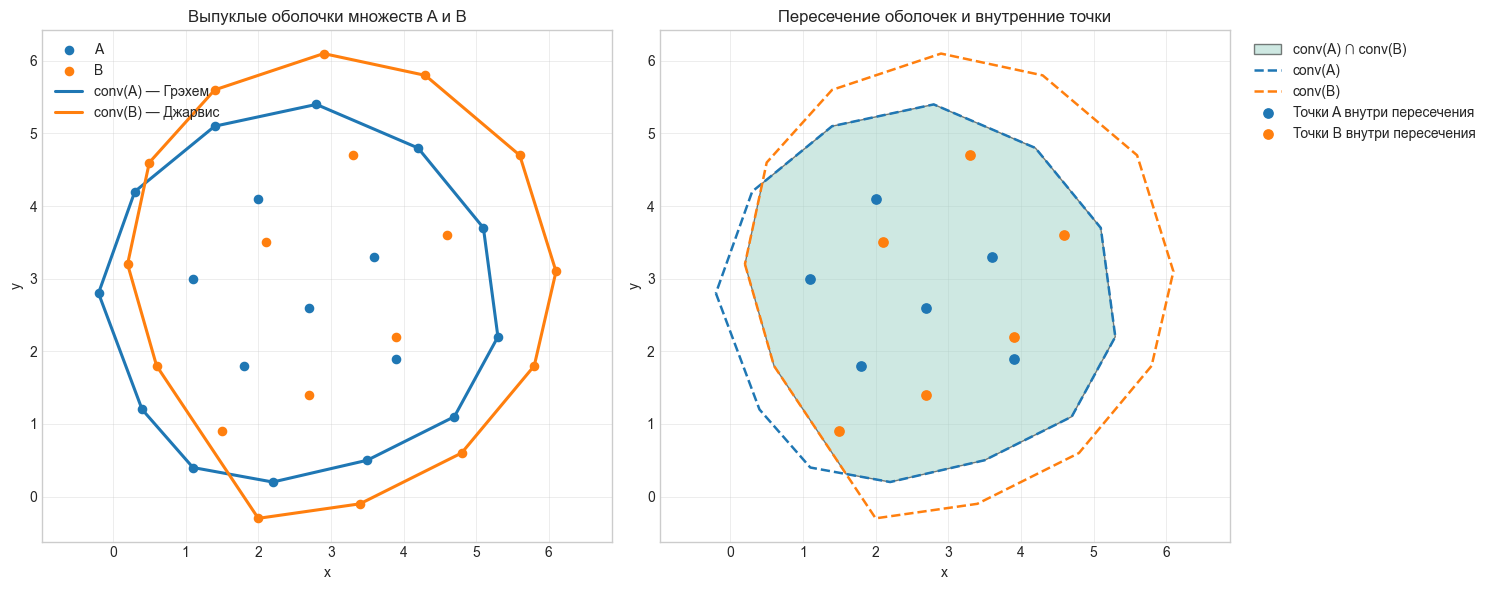

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(A[:, 0], A[:, 1], color="tab:blue", s=35, label="A")
axes[0].scatter(B[:, 0], B[:, 1], color="tab:orange", s=35, label="B")
path_A = np.vstack([hull_A, hull_A[0]])
path_B = np.vstack([hull_B, hull_B[0]])
axes[0].plot(path_A[:, 0], path_A[:, 1], color="tab:blue", linewidth=2.2, label="conv(A) — Грэхем")
axes[0].plot(path_B[:, 0], path_B[:, 1], color="tab:orange", linewidth=2.2, label="conv(B) — Джарвис")
axes[0].set_title("Выпуклые оболочки множеств A и B")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].axis("equal")
axes[0].legend(loc="upper left")

axes[1].add_patch(Polygon(intersection_hulls, closed=True, facecolor="#9fd3c7", edgecolor="black", alpha=0.5, label="conv(A) ∩ conv(B)"))
axes[1].plot(path_A[:, 0], path_A[:, 1], color="tab:blue", linewidth=1.8, linestyle="--", label="conv(A)")
axes[1].plot(path_B[:, 0], path_B[:, 1], color="tab:orange", linewidth=1.8, linestyle="--", label="conv(B)")
if len(inside_A):
    axes[1].scatter(inside_A[:, 0], inside_A[:, 1], color="tab:blue", s=45, label="Точки A внутри пересечения")
if len(inside_B):
    axes[1].scatter(inside_B[:, 0], inside_B[:, 1], color="tab:orange", s=45, label="Точки B внутри пересечения")
axes[1].set_title("Пересечение оболочек и внутренние точки")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].axis("equal")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

plt.tight_layout()
plt.show()


## Задание 4.2. Близость

Возьмем множество точек `S = {S1, ..., S10}`.

Для него:
- строится диаграмма Вороного точным пересечением полуплоскостей;
- ищется ближайшая пара по графу Делоне и рекурсивным `divide-and-conquer`;
- строится граф Делоне как двойственный объект к диаграмме Вороного.


In [5]:
S = np.array([
    (0.6, 1.0), (2.2, 0.8), (4.2, 1.3), (1.3, 2.8), (3.1, 2.5),
    (5.1, 3.4), (0.9, 5.0), (2.8, 4.7), (4.7, 5.3), (3.5, 6.7),
], dtype=float)
labels = [f"S{i + 1}" for i in range(len(S))]

voronoi = voronoi_cells(S, margin=2.5)
triangles = delaunay_triangles(S)
delaunay_edges = delaunay_edges_from_triangles(triangles)

voronoi_adjacency = []
for i in range(len(S)):
    for j in range(i + 1, len(S)):
        edge = shared_edge(voronoi[i], voronoi[j])
        if edge is not None:
            voronoi_adjacency.append((i, j, edge))

nearest_dual = min(delaunay_edges, key=lambda edge: np.linalg.norm(S[edge[0]] - S[edge[1]]))
nearest_dual_distance = np.linalg.norm(S[nearest_dual[0]] - S[nearest_dual[1]])

nearest_dc_distance, nearest_dc_pair = nearest_pair_divide_conquer(S)
nearest_dc_pair = tuple(sorted((tuple(nearest_dc_pair[0]), tuple(nearest_dc_pair[1]))))
nearest_bruteforce = min(
    itertools.combinations(range(len(S)), 2),
    key=lambda edge: np.linalg.norm(S[edge[0]] - S[edge[1]])
)
nearest_bruteforce_distance = np.linalg.norm(S[nearest_bruteforce[0]] - S[nearest_bruteforce[1]])

assert abs(nearest_dual_distance - nearest_dc_distance) < 1e-9
assert abs(nearest_bruteforce_distance - nearest_dc_distance) < 1e-9

print("Точки множества S:")
for label, point in zip(labels, S):
    print(f"  {label} = {format_point(point)}")
print()
print("Количество ячеек Вороного:", len(voronoi))
print("Количество треугольников Делоне:", len(triangles))
print("Количество рёбер Делоне:", len(delaunay_edges))
print()
print("Ближайшая пара по графу Делоне:", labels[nearest_dual[0]], labels[nearest_dual[1]], nearest_dual_distance)
print("Ближайшая пара по divide-and-conquer:", nearest_dc_pair, nearest_dc_distance)
print("Ближайшая пара по полному перебору:", nearest_bruteforce, nearest_bruteforce_distance)
print()
print("Треугольники Делоне:")
print(triangles)


Точки множества S:
  S1 = (0.600, 1.000)
  S2 = (2.200, 0.800)
  S3 = (4.200, 1.300)
  S4 = (1.300, 2.800)
  S5 = (3.100, 2.500)
  S6 = (5.100, 3.400)
  S7 = (0.900, 5.000)
  S8 = (2.800, 4.700)
  S9 = (4.700, 5.300)
  S10 = (3.500, 6.700)

Количество ячеек Вороного: 10
Количество треугольников Делоне: 11
Количество рёбер Делоне: 20

Ближайшая пара по графу Делоне: S1 S2 1.61245154965971
Ближайшая пара по divide-and-conquer: ((np.float64(0.6), np.float64(1.0)), (np.float64(2.2), np.float64(0.8))) 1.61245154965971
Ближайшая пара по полному перебору: (0, 1) 1.61245154965971

Треугольники Делоне:
[(0, 1, 3), (0, 3, 6), (1, 2, 4), (1, 4, 3), (2, 5, 4), (3, 4, 7), (3, 7, 6), (4, 5, 7), (5, 8, 7), (6, 7, 9), (7, 8, 9)]


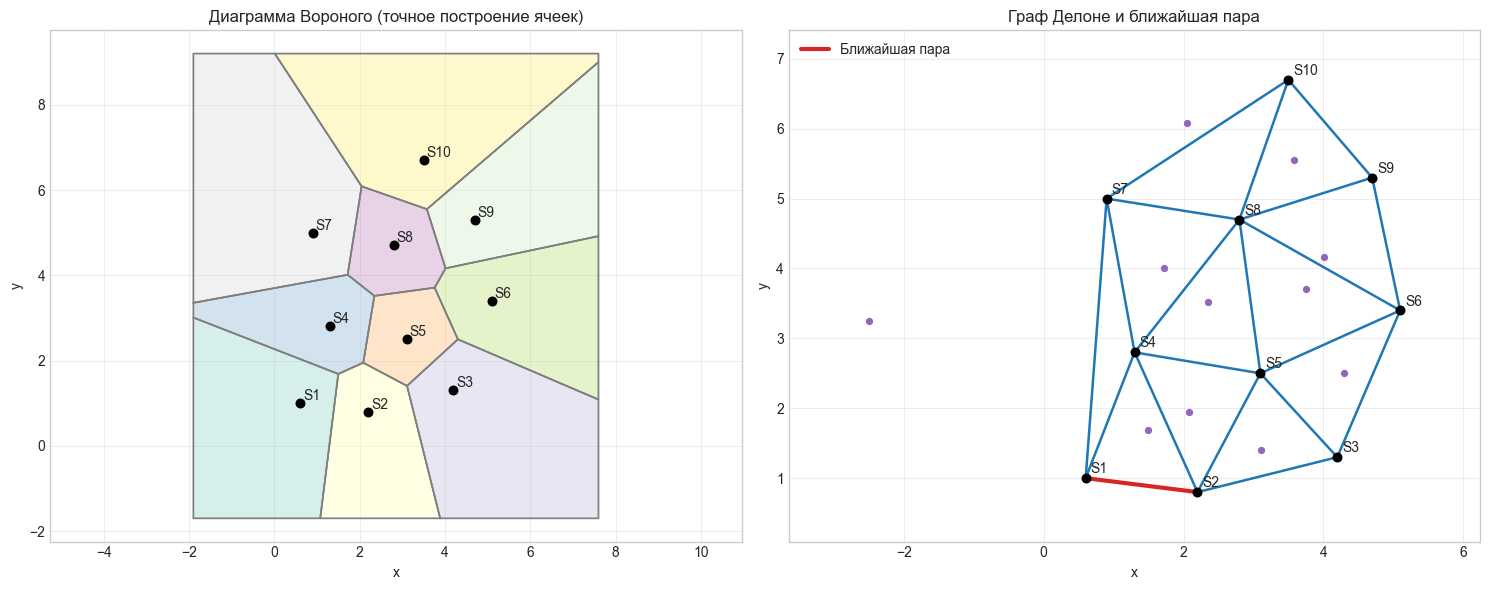

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = plt.cm.Set3(np.linspace(0, 1, len(voronoi)))
for index, cell in enumerate(voronoi):
    axes[0].add_patch(Polygon(cell, closed=True, facecolor=colors[index], edgecolor="tab:gray", alpha=0.35))
    path = np.vstack([cell, cell[0]])
    axes[0].plot(path[:, 0], path[:, 1], color="tab:gray", linewidth=1.2)
axes[0].scatter(S[:, 0], S[:, 1], color="black", s=38, zorder=5)
for label, point in zip(labels, S):
    axes[0].text(point[0] + 0.07, point[1] + 0.07, label)
axes[0].set_title("Диаграмма Вороного (точное построение ячеек)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].axis("equal")

for i, j in delaunay_edges:
    axes[1].plot([S[i, 0], S[j, 0]], [S[i, 1], S[j, 1]], color="tab:blue", linewidth=1.8)
for triangle in triangles:
    center = circumcenter(S[triangle[0]], S[triangle[1]], S[triangle[2]])
    axes[1].scatter(center[0], center[1], color="tab:purple", s=18, zorder=4)
axes[1].plot(
    [S[nearest_dual[0], 0], S[nearest_dual[1], 0]],
    [S[nearest_dual[0], 1], S[nearest_dual[1], 1]],
    color="tab:red",
    linewidth=3.0,
    label="Ближайшая пара",
)
axes[1].scatter(S[:, 0], S[:, 1], color="black", s=38, zorder=5)
for label, point in zip(labels, S):
    axes[1].text(point[0] + 0.07, point[1] + 0.07, label)
axes[1].set_title("Граф Делоне и ближайшая пара")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].axis("equal")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()


## Вывод

В ноутбуке выполнена лабораторная №4:
- выпуклые оболочки построены алгоритмами Грэхема и Джарвиса;
- найдены их периметры, площади, пересечение и внутренние точки исходных множеств;
- диаграмма Вороного построена точным геометрическим способом;
- ближайшая пара получена по графу Делоне и проверена рекурсивным `divide-and-conquer`;
- граф Делоне построен по условию пустой описанной окружности и визуализирован вместе с ближайшей парой.
